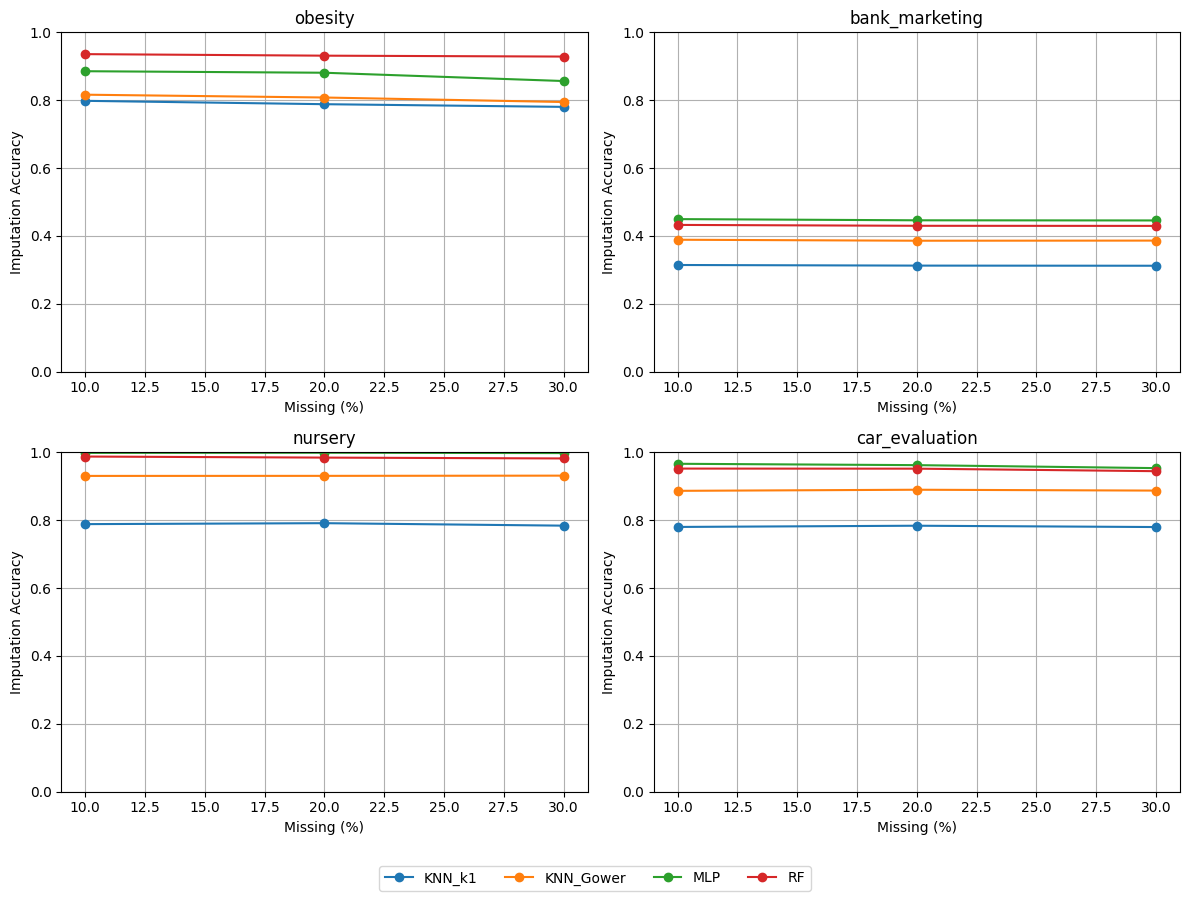

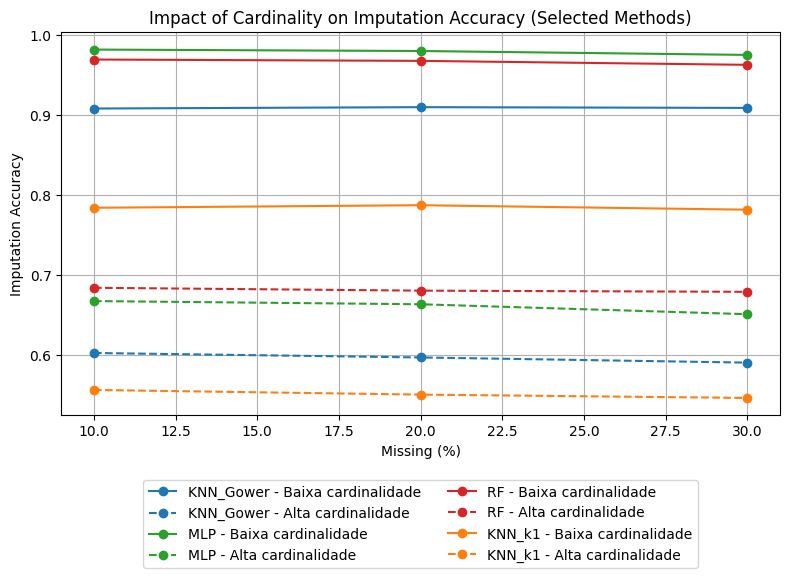

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# 1️⃣ BASELINE KNN k=1 (NN)
# =========================================================

baseline_data = [
    ("obesity", 0.1, 0.7980, 0.7999),
    ("obesity", 0.2, 0.7881, 0.7915),
    ("obesity", 0.3, 0.7802, 0.7800),

    ("bank_marketing", 0.1, 0.3143, 0.3114),
    ("bank_marketing", 0.2, 0.3125, 0.3098),
    ("bank_marketing", 0.3, 0.3121, 0.3083),

    ("nursery", 0.1, 0.7883, 0.7737),
    ("nursery", 0.2, 0.7911, 0.7621),
    ("nursery", 0.3, 0.7838, 0.7484),

    ("car_evaluation", 0.1, 0.7800, 0.7604),
    ("car_evaluation", 0.2, 0.7836, 0.7528),
    ("car_evaluation", 0.3, 0.7797, 0.7471),
]

baseline = pd.DataFrame(
    baseline_data,
    columns=["dataset", "missing_frac", "imp_mean", "clf_mean"]
)
baseline["algorithm"] = "KNN_k1"


# =========================================================
# 2️⃣ CARREGAR KNN (APENAS KNN_Gower)
# =========================================================

knn = pd.read_csv("results/KNN.csv")
knn.columns = knn.columns.str.strip().str.lower()

knn_gower = knn[["dataset", "missing_frac", "imp_gower_mean", "clf_gower_mean"]].copy()
knn_gower = knn_gower.rename(columns={
    "imp_gower_mean": "imp_mean",
    "clf_gower_mean": "clf_mean"
})
knn_gower["algorithm"] = "KNN_Gower"


# =========================================================
# 3️⃣ CARREGAR MLP E RF
# =========================================================

def load_model_csv(path, imp_col, clf_col, algo_name):
    df = pd.read_csv(path, sep=";")
    df.columns = df.columns.str.strip().str.lower()
    df = df[["dataset", "missing_frac", imp_col, clf_col]].copy()
    df = df.rename(columns={imp_col: "imp_mean", clf_col: "clf_mean"})
    df["algorithm"] = algo_name
    return df

mlp = load_model_csv("results/MLP.csv", "imp_mlp_mean", "clf_mlp_mean", "MLP")
rf = load_model_csv("results/RF.csv", "imp_rf_mean", "clf_rf_mean", "RF")


# =========================================================
# 4️⃣ CONSOLIDAR
# =========================================================

summary = pd.concat([baseline, knn_gower, mlp, rf], ignore_index=True)

# selecionar apenas bases que queremos
bases = ["obesity", "bank_marketing", "nursery", "car_evaluation"]
summary = summary[summary["dataset"].isin(bases)]


# =========================================================
# 5️⃣ DEFINIR CARDINALIDADE
# =========================================================

cardinality_class = {
    "obesity": "Alta",
    "bank_marketing": "Alta",
    "nursery": "Baixa",
    "car_evaluation": "Baixa"
}
summary["cardinality"] = summary["dataset"].map(cardinality_class)


# =========================================================
# 6️⃣ GRÁFICO IMPUTAÇÃO POR BASE
# =========================================================

algos_to_plot = ["KNN_k1", "KNN_Gower", "MLP", "RF"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for i, base in enumerate(bases):
    ax = axes[i]
    sub = summary[summary["dataset"] == base]
    for algo in algos_to_plot:
        data_algo = sub[sub["algorithm"] == algo]
        if len(data_algo) > 0:
            ax.plot(
                data_algo["missing_frac"] * 100,
                data_algo["imp_mean"],
                marker="o",
                label=algo
            )
    ax.set_title(base)
    ax.set_xlabel("Missing (%)")
    ax.set_ylabel("Imputation Accuracy")
    ax.set_ylim(0, 1)
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()


# =========================================================
# 7️⃣ GRÁFICO CARDINALIDADE (MÉDIA POR CARDINALIDADE)
# =========================================================

fig, ax = plt.subplots(figsize=(8, 6))

algorithms = ["KNN_Gower", "MLP", "RF", "KNN_k1"]
cardinalities = ["Baixa", "Alta"]

colors = {
    "KNN_Gower": "tab:blue",
    "MLP": "tab:green",
    "RF": "tab:red",
    "KNN_k1": "tab:orange"
}
linestyles = {"Baixa": "-", "Alta": "--"}

for algo in algorithms:
    for card in cardinalities:
        sub = summary[(summary["algorithm"] == algo) & (summary["cardinality"] == card)]
        if len(sub) == 0:
            continue
        grouped = sub.groupby("missing_frac")["imp_mean"].mean()
        ax.plot(
            grouped.index * 100,
            grouped.values,
            marker="o",
            color=colors[algo],
            linestyle=linestyles[card],
            label=f"{algo} - {card} cardinalidade"
        )

ax.set_xlabel("Missing (%)")
ax.set_ylabel("Imputation Accuracy")
ax.set_title("Impact of Cardinality on Imputation Accuracy (Selected Methods)")
ax.grid(True)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.15),
    ncol=2
)
plt.tight_layout()
plt.show()

In [13]:
cardinality_class = {
    "obesity": "Alta",
    "bank_marketing": "Alta",
    "nursery": "Baixa",
    "car_evaluation": "Baixa"
}

display(cardinality_class)

{'obesity': 'Alta',
 'bank_marketing': 'Alta',
 'nursery': 'Baixa',
 'car_evaluation': 'Baixa'}

In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

# Função V de Cramer
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Ler dataset
columns = ["parents", "has_nurs", "form", "children", "housing", "finance", "social", "health", "class"]
df = pd.read_csv("data/nursery/nursery.data", header=None, names=columns)

# Criar matriz vazia
v_matrix = pd.DataFrame(np.zeros((len(columns), len(columns))), columns=columns, index=columns)

# Preencher matriz com V de Cramer
for i in range(len(columns)):
    for j in range(len(columns)):
        if i == j:
            v_matrix.iloc[i,j] = 1.0  # diagonal é perfeita correlação
        else:
            v_matrix.iloc[i,j] = cramers_v(df[columns[i]], df[columns[j]])

# Mostrar matriz
print(v_matrix)

           parents  has_nurs      form  children   housing  finance    social  \
parents   1.000000  0.000000  0.000000   0.00000  0.000000  0.00000  0.000000   
has_nurs  0.000000  1.000000  0.000000   0.00000  0.000000  0.00000  0.000000   
form      0.000000  0.000000  1.000000   0.00000  0.000000  0.00000  0.000000   
children  0.000000  0.000000  0.000000   1.00000  0.000000  0.00000  0.000000   
housing   0.000000  0.000000  0.000000   0.00000  1.000000  0.00000  0.000000   
finance   0.000000  0.000000  0.000000   0.00000  0.000000  1.00000  0.000000   
social    0.000000  0.000000  0.000000   0.00000  0.000000  0.00000  1.000000   
health    0.000000  0.000000  0.000000   0.00000  0.000000  0.00000  0.000000   
class     0.213636  0.245821  0.046911   0.07188  0.111596  0.07473  0.105963   

            health     class  
parents   0.000000  0.213636  
has_nurs  0.000000  0.245821  
form      0.000000  0.046911  
children  0.000000  0.071880  
housing   0.000000  0.111596  
fin

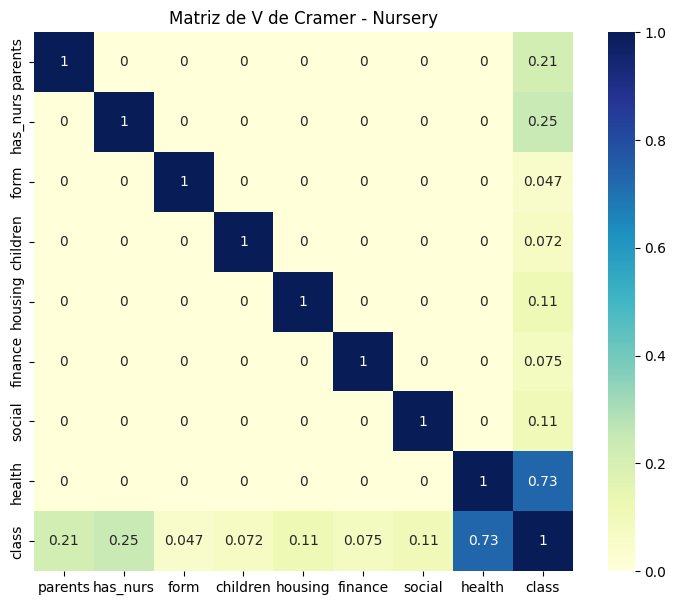

In [19]:
plt.figure(figsize=(9,7))
sns.heatmap(v_matrix, annot=True, cmap="YlGnBu", vmin=0, vmax=1, square=True)
plt.title("Matriz de V de Cramer - Nursery")
plt.show()